# **📦 Classification Algorithms – E-Commerce Logistics & Risk Engine**

In modern e-commerce operations, shipping a package isn't just about moving an item from point A to point B. It involves complex decisions surrounding delivery speed, fulfillment risk, customer satisfaction, and financial return costs. This notebook uses a unified dataset merged from two Kaggle sources—**E-Commerce Delivery Performance Data** and **Retail Return Risk Data**—to explore how different classification paradigms solve real-world logistical challenges.

## **Case Study: Predicting Logistics & Risk Outcomes**

Instead of looking at shipping as a simple win/loss binary event, we model the multi-stage life cycle of an order from purchase to final delivery.

### 1. Binary Classification: Late Delivery Risk (`Is_Late`)
* **Target Variable ($y$):** Binary indicator (`1` = Delivery SLA Breached, `0` = On-Time).
* **Key Features ($X$):** Carrier Type, Transit Distance, Shipping Priority Mode, Warehouse Processing Time, Regional Seasonality Index.
* **Objective:** Identify high-risk shipments *before* they leave the warehouse so logistics teams can upgrade shipping speeds or rerun routing scripts.

### 2. Multiclass Classification: Order Fulfillment Status (`Status`)
* **Target Variable ($y$):** One of four discrete states (`On-Time Delivery`, `Delayed Transit`, `Returned/Damaged`, `Cancelled`).
* **Key Features ($X$):** Package Weight, Item Category, Payment Method, Delivery Distance, Historical Carrier Reliability Score.
* **Objective:** Classify the exact operational outcome to automate customer service notifications and balance warehouse inventory reserves.

### 3. Ordinal Classification: Customer Churn / Delay Severity (`Severity_Tier`)
* **Target Variable ($y$):** Ordered Risk Level (`Low Risk` < `Medium Risk` < `High Risk` < `Critical Action Required`).
* **Key Features ($X$):** Accumulated Delay Days, Customer Lifetime Value (CLV), Order Value, Item Fragility Rating.
* **Objective:** Account for inherent ranking where a "Critical" failure is worse than a "Medium" delay, using thresholding and custom ordinal scoring.

### 4. Cost-Sensitive / Imbalanced Classification: Return Risk (`Is_Returned`)
* **Target Variable ($y$):** Rare Event (`1` = Item Returned, `0` = Item Retained).
* **Key Features ($X$):** Item Category, Price Point, Discount Percentage, Customer Historical Return Rate, Sizing Granularity.
* **Objective:** Address heavily imbalanced target distributions (~5–8% return rates) using techniques like **SMOTE**, **Focal Loss**, and custom decision boundaries based on financial loss metrics rather than basic accuracy.

---

## **Why Classification Works for Supply Chain Analytics**

* **Actionable Decision Thresholds:** Unlike regression models that predict exact continuous numbers (like hours delayed), classification directly maps inputs into actionable business categories—such as triggering an automated customer email or flagging a package for manual inspection.
* **Handling Complex Non-Linear Signals:** Real-world logistics metrics like carrier efficiency or regional weather disruptions rarely scale in a straight line. Tree-based classifiers naturally group non-linear interactions across shipping methods, distances, and order values.
* **Financial Risk Mitigation:** Predicting specific risk tiers allows businesses to allocate resources efficiently—spending extra postage or customer support effort only on orders identified as high-risk.

---

## **💡 What is Classification?**

Classification is a foundational supervised learning paradigm where the goal is to map input features ($X$) to discrete, categorical target labels ($y$). Unlike regression, which estimates a continuous variable, classification draws decision boundaries through the feature space to categorize each data point into a specific class.

### Key Paradigms Covered in This Notebook:

* **Binary Classification:** Separating data into two mutually exclusive classes using a decision threshold (e.g., Logistic Regression probability cutoff).
* **Multiclass Classification:** Categorizing data into three or more non-overlapping categories using algorithms like **Softmax Regression** or **One-vs-Rest (OvR)** strategies.
* **Ordinal Classification:** Handling target variables where categories possess a natural rank or sequence, preserving the relative order between classes.
* **Imbalanced Classification:** Adjusting model learning rates and evaluation metrics (Precision-Recall AUC, F1-Score) when one class occurs far less frequently than others.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/final_data.csv
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/__results__.html
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/__resultx__.html
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/__notebook__.ipynb
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/__output__.json
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/custom.css
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/__results___files/__results___77_2.png
/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/__results___files/__results___78_2.png


In [2]:
ecom_data = pd.read_csv('/kaggle/input/notebooks/tarzon/brazilian-e-commerce-public-dataset-by-olist/final_data.csv')

print(f"E-com data : {ecom_data.shape}")

E-com data : (117013, 43)


### 2. Multiclass Classification: Order Fulfillment Status (`Status`)
* **Target Variable ($y$):** One of four discrete states (`On-Time Delivery`, `Delayed Transit`, `Returned/Damaged`, `Cancelled`).
* **Key Features ($X$):** Package Weight, Item Category, Payment Method, Delivery Distance, Historical Carrier Reliability Score.
* **Objective:** Classify the exact operational outcome to automate customer service notifications and balance warehouse inventory reserves.

In [3]:
ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117013 entries, 0 to 117012
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     117013 non-null  int64  
 1   review_id                      117013 non-null  object 
 2   order_id                       117013 non-null  object 
 3   review_score                   117013 non-null  int64  
 4   review_comment_title           13847 non-null   object 
 5   review_comment_message         49549 non-null   object 
 6   review_creation_date           117013 non-null  object 
 7   review_answer_timestamp        117013 non-null  object 
 8   customer_id                    117013 non-null  object 
 9   order_status                   117013 non-null  object 
 10  order_purchase_timestamp       117013 non-null  object 
 11  order_approved_at              116998 non-null  object 
 12  order_delivered_carrier_date  

In [4]:
ecom_data['order_status'].value_counts()

order_status
delivered      114557
shipped          1160
canceled          548
processing        369
invoiced          369
unavailable         7
approved            3
Name: count, dtype: int64

## **Exploratory Data Analysis**

--- Dataset Dimensions ---
(117013, 43)

--- Raw Order Status Distribution ---
order_status
delivered      114557
shipped          1160
canceled          548
processing        369
invoiced          369
unavailable         7
approved            3
Name: count, dtype: int64

--- Missing Values Overview ---
price                               0
freight_value                       0
product_weight_g                   20
order_delivered_customer_date    2457
order_estimated_delivery_date       0
dtype: int64


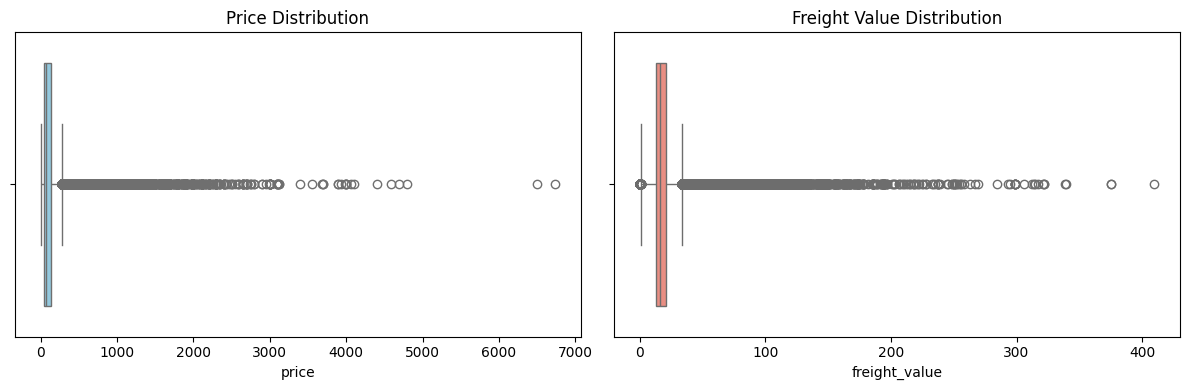

In [5]:
# Basic Data Inspection
print("--- Dataset Dimensions ---")
print(ecom_data.shape)

print("\n--- Raw Order Status Distribution ---")
print(ecom_data['order_status'].value_counts(dropna=False))

print("\n--- Missing Values Overview ---")
missing = ecom_data[['price', 'freight_value', 'product_weight_g', 'order_delivered_customer_date', 'order_estimated_delivery_date']].isnull().sum()
print(missing)

# Visualization of main numeric distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=ecom_data, x='price', ax=axes[0], color='skyblue')
axes[0].set_title('Price Distribution')
sns.boxplot(data=ecom_data, x='freight_value', ax=axes[1], color='salmon')
axes[1].set_title('Freight Value Distribution')
plt.tight_layout()
plt.show()

## **Target Construction & Feature Engineering**

In [6]:
df = ecom_data.copy()

# Parse datetime columns
time_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# 1. Define Multiclass Target (fulfillment_status)
def assign_fulfillment_status(row):
    status = row['order_status']
    if status == 'delivered':
        if pd.notnull(row['order_delivered_customer_date']) and pd.notnull(row['order_estimated_delivery_date']):
            if row['order_delivered_customer_date'] <= row['order_estimated_delivery_date']:
                return 'On-Time'
            else:
                return 'Late'
        return 'On-Time'
    elif status in ['shipped', 'processing', 'invoiced', 'approved']:
        return 'In-Transit'
    elif status in ['canceled', 'unavailable']:
        return 'Canceled'
    return np.nan

df['target_status'] = df.apply(assign_fulfillment_status, axis=1)

# 2. Pre-Fulfillment Feature Engineering (Zero Target Leakage)
df['approval_delay_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600.0
df['promised_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

# Temporal Features
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['is_weekend'] = df['purchase_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Physical & Financial Attributes
df['product_vol_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
df['freight_ratio'] = df['freight_value'] / (df['price'] + 1e-5)

# Select Predictors and Target
features = [
    'price', 'freight_value', 'payment_installments', 'payment_sequential',
    'product_weight_g', 'product_vol_cm3', 'freight_ratio', 
    'approval_delay_hours', 'promised_delivery_days', 
    'purchase_month', 'purchase_dayofweek', 'is_weekend',
    'customer_state', 'payment_type', 'product_category_name'
]

X = df[features].copy()
y = df['target_status'].copy()

# Fill missing numerical values with medians
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Fill missing categorical values
cat_cols = X.select_dtypes(include=['object']).columns
X[cat_cols] = X[cat_cols].fillna('Unknown')

print("Target Class Counts:")
print(y.value_counts())

Target Class Counts:
target_status
On-Time       105727
Late            8830
In-Transit      1901
Canceled         555
Name: count, dtype: int64


## **Preprocessing Pipeline & Model Training**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

# 1. Encode Target
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

# Print mapping to ensure dictionary keys match encoded integers
print("Class Mapping:")
for idx, name in enumerate(label_enc.classes_):
    print(f"Class {idx}: {name}")

# 2. Define Custom Weights (adjust these values to fine-tune precision/recall)
# Order: [Canceled, In-Transit, Late, On-Time]
custom_class_weights = {
    0: 15.0,  # Canceled (~0.5% of data)
    1: 8.0,   # In-Transit (~1.6% of data)
    2: 4.0,   # Late (~7.5% of data)
    3: 1.0    # On-Time (~90% of data)
}

# 3. Column Transformer
cat_features = ['customer_state', 'payment_type', 'product_category_name']
num_features = [c for c in X.columns if c not in cat_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Pipeline with corrected class_weight parameter
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        class_weight=custom_class_weights,  # Correct singular parameter name
        n_estimators=150,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

Class Mapping:
Class 0: Canceled
Class 1: In-Transit
Class 2: Late
Class 3: On-Time
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1884
[LightGBM] [Info] Number of data points in the train set: 93610, number of used features: 110
[LightGBM] [Info] Start training from score -2.984141
[LightGBM] [Info] Start training from score -2.381451
[LightGBM] [Info] Start training from score -1.538955
[LightGBM] [Info] Start training from score -0.442551


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## **Performance Analysis**

--- Classification Report ---
              precision    recall  f1-score   support

    Canceled       0.64      0.16      0.26       111
  In-Transit       0.59      0.07      0.12       380
        Late       0.34      0.34      0.34      1766
     On-Time       0.93      0.95      0.94     21146

    accuracy                           0.88     23403
   macro avg       0.63      0.38      0.41     23403
weighted avg       0.88      0.88      0.88     23403



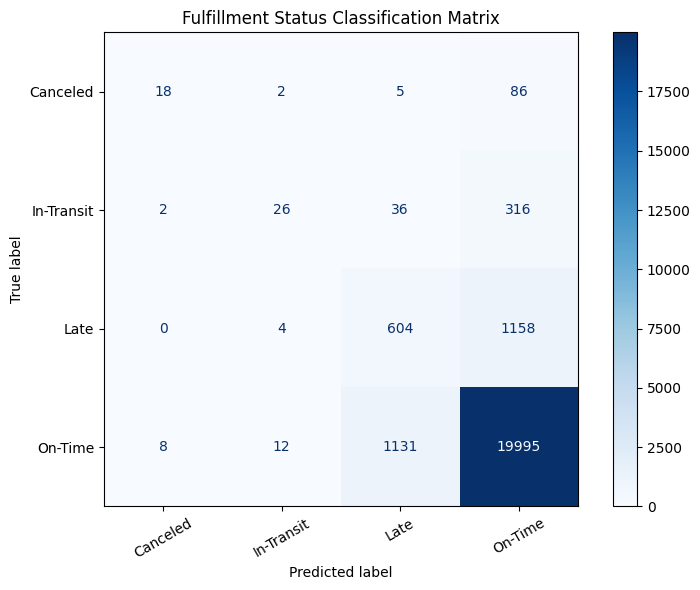

/tmp/ipykernel_16/787938224.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')


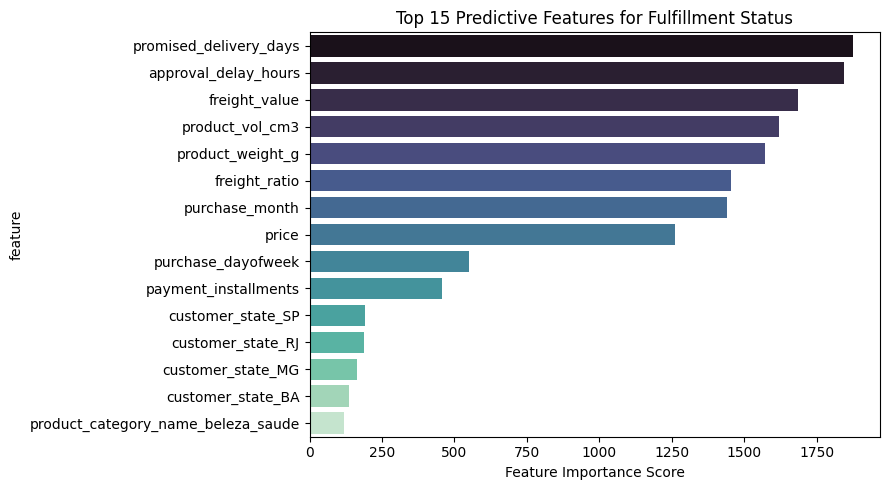

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Display Classification Metrics
class_names = label_enc.classes_
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Fulfillment Status Classification Matrix')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Extract Feature Importances
classifier = model_pipeline.named_steps['classifier']
ohe_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_features, ohe_feature_names])

importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': classifier.feature_importances_
}).sort_values(by='importance', ascending=False).head(15)

# Plot Top Features
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')
plt.title('Top 15 Predictive Features for Fulfillment Status')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()